In [4]:
pip install ultralytics open-clip-torch pillow notebook

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 32.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 44.6 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 34.1 MB/s  0:00:00
  Attempting uninstall: jupyterlab90m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/4 [open-clip-torch]
    Found existing installation: jupyterlab 4.5.4━━━━━━━━━━━━━ 1/4 [open-clip-torch]
    Uninstalling jupyterlab-4.5.4:━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/4 [open-clip-torch]
      Successfully uninstalled jupyterlab-4.5.4━━━━━━━━━━━━━━━ 1/4 [open-clip-torch]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [notebook]3/4 [notebook]b]]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import cv2
from ultralytics import YOLO

# 1. Load the "brain" you downloaded from Colab
model = YOLO('best.pt') 

# 2. Run detection on a new shelf photo
results = model.predict(source='shelf_photo.jpg', save=True, conf=0.4)

# 3. Logic: Count the detections
for result in results:
    count_items = (result.boxes.cls == 1).sum().item() # Class 1 is Retail-items
    count_gaps = (result.boxes.cls == 0).sum().item()  # Class 0 is Empty Gap
    
    print(f"Analysis Complete:")
    print(f"Items found: {int(count_items)}")
    print(f"Gaps found: {int(count_gaps)}")
    
    if count_gaps > 0:
        print("Status: Restock required!")
    else:
        print("Status: Shelf is full.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/glenzhang/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.



FileNotFoundError: shelf_photo.jpg does not exist

In [3]:
import cv2
from ultralytics import YOLO
from PIL import Image

# 1. Load your newly trained model
model = YOLO('best.pt') 

# 2. Run inference
results = model('test_10.jpg')[0]

# 3. Separate Gaps and Items
gaps = [b for b in results.boxes if int(b.cls) == 0] # Class 0 = Empty Gap
items = [b for b in results.boxes if int(b.cls) == 1] # Class 1 = Retail-items

def get_neighbors(gap_box, all_items):
    gx1, gy1, gx2, gy2 = gap_box.xyxy[0]
    left_neighbor = None
    right_neighbor = None
    
    # Simple logic: Find items on the same horizontal plane (Y-axis)
    # and closest to the gap on the X-axis
    for item in all_items:
        ix1, iy1, ix2, iy2 = item.xyxy[0]
        
        # Check if item is roughly on the same shelf (Y-overlap)
        if abs(gy1 - iy1) < 50: 
            if ix2 < gx1: # Item is to the left
                if left_neighbor is None or ix2 > left_neighbor['coords'][2]:
                    left_neighbor = {'box': item, 'coords': item.xyxy[0]}
            elif ix1 > gx2: # Item is to the right
                if right_neighbor is None or ix1 < right_neighbor['coords'][0]:
                    right_neighbor = {'box': item, 'coords': item.xyxy[0]}
    
    return left_neighbor, right_neighbor

# Execute for the first detected gap
if gaps:
    left, right = get_neighbors(gaps[0], items)
    print(f"Gap found! Neighbors: Left ({'Yes' if left else 'No'}), Right ({'Yes' if right else 'No'})")


image 1/1 /Users/glenzhang/Advanced_AI/Semester project/test_10.jpg: 640x384 5 Empty Gaps, 120 Retail-itemss, 30.3ms
Speed: 1.6ms preprocess, 30.3ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 384)
Gap found! Neighbors: Left (Yes), Right (Yes)


In [1]:
import torch
import clip
from PIL import Image

In [4]:
import torch
import clip
from PIL import Image

# 1. Load CLIP
# Check for Apple GPU (MPS) instead of CUDA
if torch.backends.mps.is_available():
    device = "mps"
    print("Using Apple GPU (MPS)")
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
    print("Using CPU")
clip_model, preprocess = clip.load("ViT-B/32", device=device)

# 2. Define your possible brands/products (The "Assortment")
# Add the specific brands present in your test image here
candidate_labels = ["Durex box", "Scholl footcare", "Optrex eye drops", "Nicorette pack", "Empty shelf"]
text_inputs = clip.tokenize(candidate_labels).to(device)

def identify_brand(img_path, box_coords):
    # Open image and crop to the neighbor's coordinates
    full_img = Image.open(img_path)
    # xyxy format: [x1, y1, x2, y2]
    crop = full_img.crop((float(box_coords[0]), float(box_coords[1]), 
                          float(box_coords[2]), float(box_coords[3])))
    
    # Preprocess for CLIP
    image_input = preprocess(crop).unsqueeze(0).to(device)
    
    # Calculate features
    with torch.no_grad():
        image_features = clip_model.encode_image(image_input)
        text_features = clip_model.encode_text(text_inputs)
        
        # Pick the top label
        logits_per_image, _ = clip_model(image_input, text_inputs)
        probs = logits_per_image.softmax(dim=-1).cpu().numpy()
        
    return candidate_labels[probs.argmax()]

# 3. Use it on your found neighbors
if left:
    left_brand = identify_brand('test_10.jpg', left['coords'])
    print(f"Left Neighbor Brand: {left_brand}")
if right:
    right_brand = identify_brand('test_10.jpg', right['coords'])
    print(f"Right Neighbor Brand: {right_brand}")

Using Apple GPU (MPS)
Left Neighbor Brand: Durex box
Right Neighbor Brand: Optrex eye drops


In [5]:
import ollama

def get_retail_analysis(left_b, right_b):
    # We use llama3.2 since you already have it in your 'ollama list'
    model_name = 'llama3.2'
    
    prompt = f"""
    Context: You are an AI retail auditor. 
    Observation: I found an empty gap on a pharmacy shelf.
    Left Neighbor Product: {left_b}
    Right Neighbor Product: {right_b}
    
    Task: 
    1. Determine if the gap likely belongs to the left brand or the right brand.
    2. Suggest the most likely missing product (e.g., if it's between two Durex types, it's likely another Durex variant).
    3. Keep the answer very brief (under 30 words).
    """
    
    response = ollama.generate(model=model_name, prompt=prompt)
    return response['response']

# Execute the final logic
if 'left_brand' in locals() and 'right_brand' in locals():
    result = get_retail_analysis(left_brand, right_brand)
    print("\n--- SHELF AUDIT RESULT ---")
    print(f"Gap Context: {left_brand} | [ EMPTY ] | {right_brand}")
    print(f"AI Analysis: {result}")
else:
    print("Error: Please run the YOLO and CLIP cells first to identify neighbors!")


--- SHELF AUDIT RESULT ---
Gap Context: Durex box | [ EMPTY ] | Optrex eye drops
AI Analysis: 1. The gap likely belongs to Optrex, as a similar size and shape gap is present between Durex and Optrex.
2. A missing Optrex product, such as Optrex eye wash or Optrex multipurpose drops, would fit the observed gap.


In [6]:
# Create a list to store all results for a final summary
final_audit_report = []

print(f"Starting audit for {len(gaps)} detected gaps...\n")

for i, gap_box in enumerate(gaps):
    # 1. Get neighbors for this specific gap
    left, right = get_neighbors(gap_box, items)
    
    # 2. Identify brands (handle cases where a gap is at the very edge of the shelf)
    l_brand = identify_brand('test_10.jpg', left['coords']) if left else "Shelf Edge/Wall"
    r_brand = identify_brand('test_10.jpg', right['coords']) if right else "Shelf Edge/Wall"
    
    # 3. Get AI Analysis from Llama 3.2
    analysis = get_retail_analysis(l_brand, r_brand)
    
    # 4. Store and Print
    audit_entry = {
        "gap_id": i + 1,
        "left": l_brand,
        "right": r_brand,
        "verdict": analysis
    }
    final_audit_report.append(audit_entry)
    
    print(f"GAP #{i+1}: Between [{l_brand}] and [{r_brand}]")
    print(f"VERDICT: {analysis}\n")
    print("-" * 30)

Starting audit for 5 detected gaps...

GAP #1: Between [Durex box] and [Optrex eye drops]
VERDICT: 1. The gap likely belongs to Optrex due to its larger size and bulkier packaging compared to Durex.
2. Most likely missing product: Optrex Plus or Optrex Contact Lens Drops.

------------------------------
GAP #2: Between [Nicorette pack] and [Nicorette pack]
VERDICT: Task 1: The gap likely belongs to the right brand.

Task 2: Another Nicorette pack is the most likely missing product.

------------------------------
GAP #3: Between [Nicorette pack] and [Scholl footcare]
VERDICT: 1. The gap is likely due to Scholl, as their packaging size and shape can be more variable.
2. A missing pack of Nicorette gum or a smaller Nicorette variety is most likely missing.

------------------------------
GAP #4: Between [Nicorette pack] and [Scholl footcare]
VERDICT: Task Response:

1. The gap is likely from the left neighbor Nicorette pack due to their rectangular shape and compact size.
2. It's likely 

In [7]:
import cv2
import matplotlib.pyplot as plt

# Load the image for drawing
img = cv2.imread('test_10.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

for i, gap_box in enumerate(gaps):
    coords = gap_box['coords']
    x1, y1, x2, y2 = map(int, coords)
    
    # Draw a bounding box for the gap
    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
    
    # Put the Gap ID and the AI's brief verdict above the box
    label = f"Gap {i+1}: {final_audit_report[i]['left']} area"
    cv2.putText(img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis('off')
plt.title("Final Shelf Audit Visualization")
plt.show()

/Users/glenzhang/Advanced_AI/Semester project/ai_stable_env/lib/python3.12/site-packages/ultralytics/engine/results.py:173: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  return self.__class__(self.data[idx], self.orig_shape)


IndexError: too many indices for tensor of dimension 2

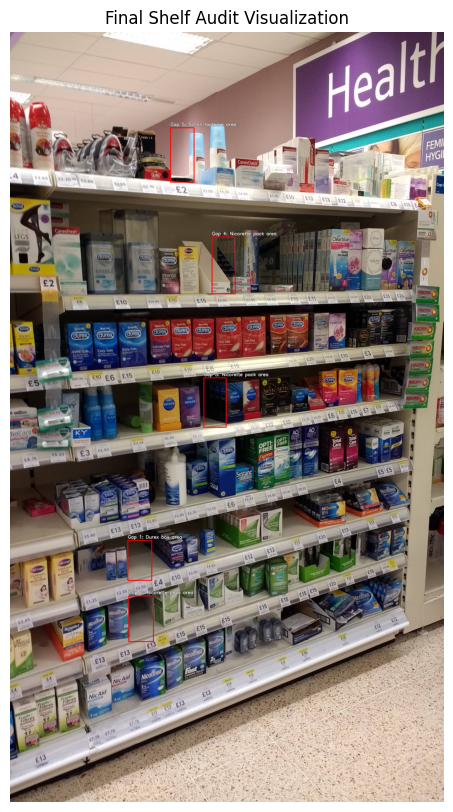

In [8]:
import cv2
import matplotlib.pyplot as plt

# Load the image for drawing
img = cv2.imread('test_10.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Use .tolist() on the boxes to make them easy to iterate over with the index 'i'
for i, gap_box in enumerate(gaps):
    # CORRECT WAY: Get the xyxy coordinates from the YOLO box object
    # .xyxy returns a tensor like [[x1, y1, x2, y2]], so we take the first row [0]
    coords = gap_box.xyxy[0].cpu().numpy() 
    x1, y1, x2, y2 = map(int, coords)
    
    # Draw a bounding box for the gap (Blue)
    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
    
    # Put the Gap ID and the AI's brief verdict above the box
    # We use .get() to avoid errors if the index i doesn't exist in our report
    left_side = final_audit_report[i]['left'] if i < len(final_audit_report) else "Unknown"
    label = f"Gap {i+1}: {left_side} area"
    
    # Draw label background for better readability
    cv2.putText(img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 4) # Outline
    cv2.putText(img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2) # Text

plt.figure(figsize=(16, 10))
plt.imshow(img)
plt.axis('off')
plt.title("Final Shelf Audit Visualization")
plt.show()